In [3]:
#import libraries
import glob
import numpy as np
import pandas as pd
import cv2 as cv
from skimage import io
from PIL import Image
import matplotlib.pylab as plt
from skimage.transform import downscale_local_mean

## Read raw image

In [4]:
img_list = glob.glob("../data/*.tif")
print(img_list)
img_path = img_list[1]

['../data/GWIN2000662_2220.tif', '../data/GWIN2000516_5331.tif']


image shape: (3685, 1251)


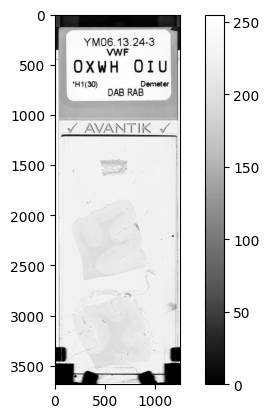

In [19]:
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
print(f"image shape: {img.shape}")
plt.imshow(img, cmap='Greys_r')
plt.colorbar()

## Crop around area of interest

cropped_image shape: (900, 951)


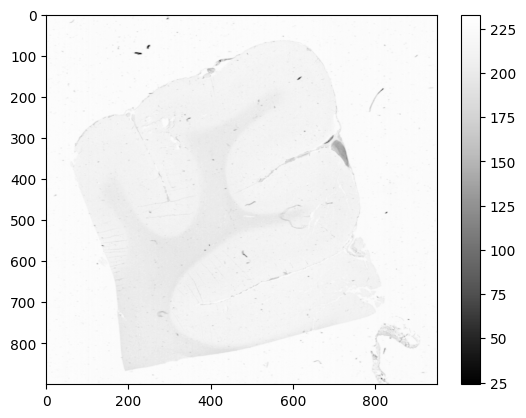

In [23]:
cropped_image = img[-1900:-1000,100:-200]
print(f"cropped_image shape: {cropped_image.shape}")
plt.imshow(cropped_image, cmap='Greys_r')
plt.colorbar()

## Intensity scaling
To increase the contrast of the image features

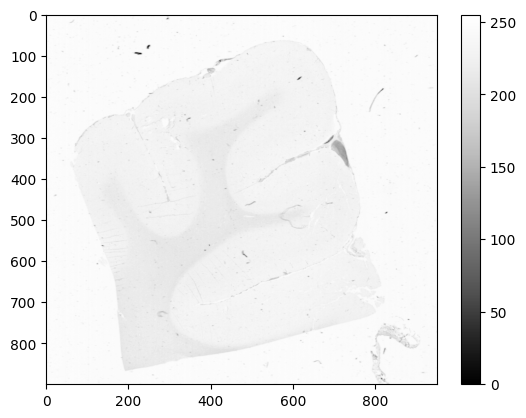

In [30]:
# Linear scaling
def linear_scaling(image):
    min_val = np.min(image)
    max_val = np.max(image)
    scaled_image = (image - min_val) / (max_val - min_val) * 255
    return scaled_image.astype(np.uint8)

scaled_image_linear = linear_scaling(cropped_image)
plt.imshow(scaled_image_linear, cmap='Greys_r')
plt.colorbar()


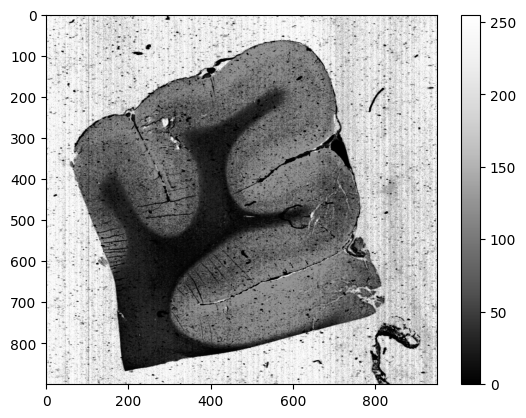

In [32]:
# Histogram equalization
equalized_image = cv.equalizeHist(cropped_image)
plt.imshow(equalized_image, cmap='Greys_r')
plt.colorbar()

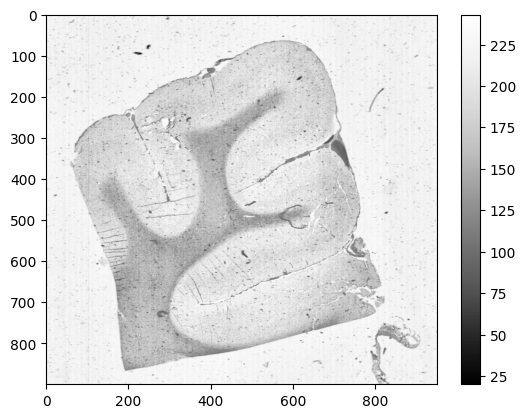

In [39]:
# CLAHE: Contrast Limited Adaptive Histogram Equalization)
# improves local contrast and enhances the definition of edges in images.
clahe = cv.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
clahe_image = clahe.apply(cropped_image)

plt.imshow(clahe_image, cmap='Greys_r')
plt.colorbar()

## Median filter 
to remove noise while keeping edges

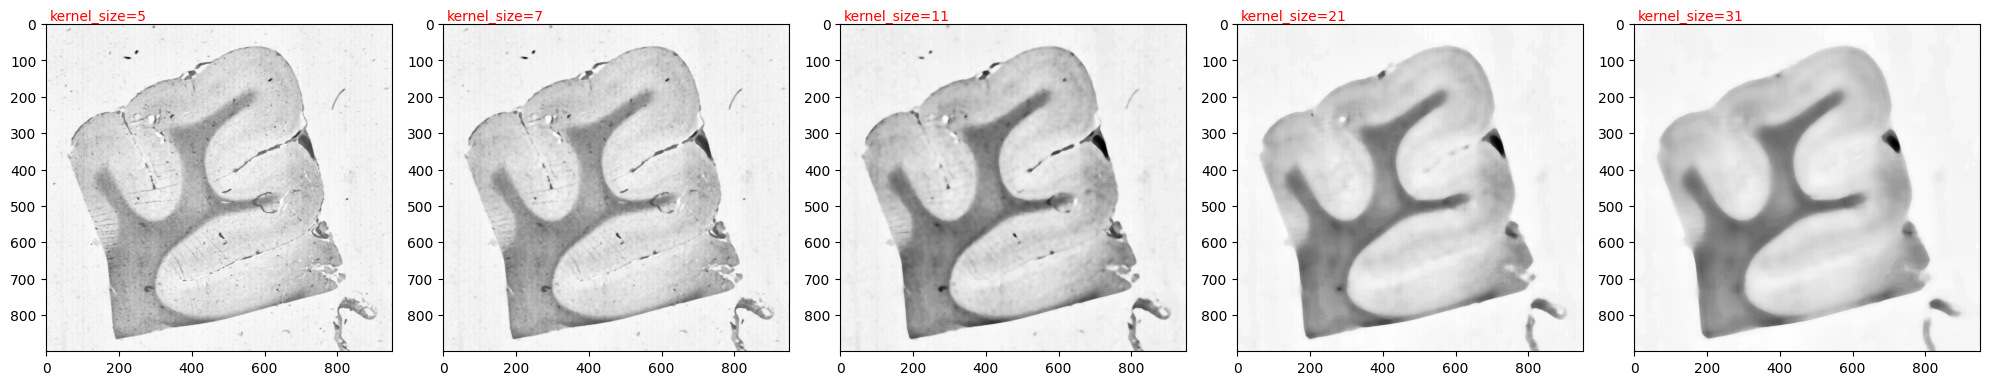

In [58]:
kernel_size_list = [5, 7, 11, 21, 31]
plt.figure(figsize=(20,4))
for i, kernel_size in enumerate(kernel_size_list) :
    plt.subplot( 1,len(kernel_size_list), i+1)
    median_filtered_image = cv.medianBlur(clahe_image, ksize=kernel_size)  # Kernel size must be odd
    plt.imshow(median_filtered_image, cmap='Greys_r')
    plt.text(10,-10,f"kernel_size={kernel_size}", color='red')
plt.tight_layout()

Let's choose a kernel size at 11.

In [59]:
median_filtered_image = cv.medianBlur(clahe_image, ksize=11)  # Kernel size must be odd

## Different downscaling techniques

downscaled_image shape: (225, 238)


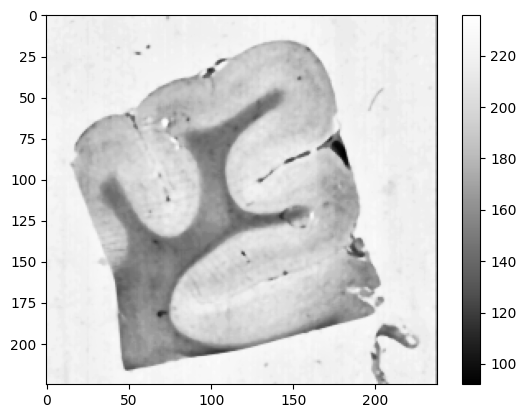

In [60]:
# Downscale by a factor of 4 (adjust as needed)
downscaled_image = downscale_local_mean(median_filtered_image, (4, 4))  # Assuming a 3D image (height, width, channels)
print(f"downscaled_image shape: {downscaled_image.shape}")
plt.imshow(downscaled_image, cmap='Greys_r')
plt.colorbar()

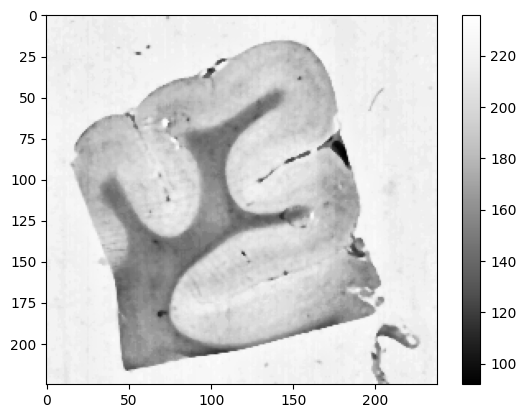

In [61]:
# bicubic downscaling
new_width = 238
new_height = 225
downscaled_image_bicubic = cv.resize(median_filtered_image, (new_width, new_height), interpolation=cv.INTER_CUBIC)
plt.imshow(downscaled_image_bicubic, cmap='Greys_r')
plt.colorbar()